# Projeto Final: análise das candidaturas da eleição de 2022

**Autores:** Felipe, Denise e Fabrício

## Datasets utilizados
- **Base principal:** consulta_cand_2022_BRASIL.csv
- **Base auxiliar:**  consulta_cand_complementar_2022_BRASIL.csv

## Perguntas que serão respondidas:
1. Cargos com mais candidaturas
2. Distribuição por gênero
3. Distribuição por raça/cor
4. Taxa de eleição por escolaridade
5. Candidaturas e eleitos por UF
6. Taxa de eleição por gênero
7. Resultado por faixa etária

## 1. Importando as bibliotecas Pandas e Numpy

In [104]:
# Para facilitar no desenvolvimento, "apelidamos" as bibliotecas no momento da importação
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Criando o DataFrame

### 2.1. Erro na primeira tentativa de criação do DataFrame

In [105]:
"""
caminho note pessoal
pasta_arquivo = "/Users/felipealbanez/Github/CAIXAVERSO_DFF/Projeto_Final_TSE_2022/consulta_cand_2022_BRASIL.csv"

caminho Trabalho
pasta_arquivo = "/Users/cxxxxxx/OneDrive - Caixa Economica Federal/Área de Trabalho/CAIXA Verso/Projeto Final/Base de dados/consulta_cand_2022_BRASIL.csv"

df_original = pd.read_csv(pasta_arquivo)
df_original.head()

erro gerado:
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xc7 in position 838: invalid continuation byte

"""

'\ncaminho note pessoal\npasta_arquivo = "/Users/felipealbanez/Github/CAIXAVERSO_DFF/Projeto_Final_TSE_2022/consulta_cand_2022_BRASIL.csv"\n\ncaminho Trabalho\npasta_arquivo = "/Users/cxxxxxx/OneDrive - Caixa Economica Federal/Área de Trabalho/CAIXA Verso/Projeto Final/Base de dados/consulta_cand_2022_BRASIL.csv"\n\ndf_original = pd.read_csv(pasta_arquivo)\ndf_original.head()\n\nerro gerado:\nUnicodeDecodeError: \'utf-8\' codec can\'t decode byte 0xc7 in position 838: invalid continuation byte\n\n'

### 2.2. Segunda tentativa - modo "a brasileira"

In [106]:
""""
sep=';': Os dados usam ponto e vírgula para separar as colunas
decimal=",": números decimais usam vírgula
encoding='latin-1': Evita erros de leitura com acentos e caracteres da língua portuguesa.
"""
# substitua o caminho abaixo pela pasta onde está salvo a base de dados .csv
# não esquecer que o nome do arquivo e a extensão deve estar inclusos

# caminho note pessoal
pasta_arquivo = "../dados/consulta_cand_2022_BRASIL.csv"

# caminho Trabalho
# pasta_arquivo = "/Users/cxxxxxx/OneDrive - Caixa Economica Federal/Área de Trabalho/CAIXA Verso/Projeto Final/Base de dados/consulta_cand_2022_BRASIL.csv"

# cria o dataframe lendo o arquivo .csv
df_original = pd.read_csv(pasta_arquivo, sep=';', decimal=',',encoding='latin-1')

In [107]:
# vizualisa as 5 primeiras linhas do dataframe
df_original.head()

,DT_GERACAO,HH_GERACAO,ANO_ELEICAO,CD_TIPO_ELEICAO,NM_TIPO_ELEICAO,NR_TURNO,CD_ELEICAO,DS_ELEICAO,DT_ELEICAO,TP_ABRANGENCIA,...,CD_GRAU_INSTRUCAO,DS_GRAU_INSTRUCAO,CD_ESTADO_CIVIL,DS_ESTADO_CIVIL,CD_COR_RACA,DS_COR_RACA,CD_OCUPACAO,DS_OCUPACAO,CD_SIT_TOT_TURNO,DS_SIT_TOT_TURNO
0,26/08/2026,03:15:18,2022,2,ELEIÇÃO ORDINÁRIA,1,546,Eleições Gerais Estaduais 2022,02/10/2022,ESTADUAL,...,-4,NÃO DIVULGÁVEL,-4,NÃO DIVULGÁVEL,-4,NÃO DIVULGÁVEL,-4,NÃO DIVULGÁVEL,5,SUPLENTE
1,26/08/2026,03:15:18,2022,2,ELEIÇÃO ORDINÁRIA,1,546,Eleições Gerais Estaduais 2022,02/10/2022,ESTADUAL,...,5,ENSINO MÉDIO INCOMPLETO,9,DIVORCIADO(A),2,PRETA,257,EMPRESÁRIO,4,NÃO ELEITO
2,26/08/2026,03:15:18,2022,1,ELEIÇÃO SUPLEMENTAR,1,6278,Eleição Suplementar Governador 2026,21/06/2026,ESTADUAL,...,8,SUPERIOR COMPLETO,9,DIVORCIADO(A),2,PRETA,125,ADMINISTRADOR,4,NÃO ELEITO
3,26/08/2026,03:15:18,2022,2,ELEIÇÃO ORDINÁRIA,1,546,Eleições Gerais Estaduais 2022,02/10/2022,ESTADUAL,...,-4,NÃO DIVULGÁVEL,-4,NÃO DIVULGÁVEL,-4,NÃO DIVULGÁVEL,-4,NÃO DIVULGÁVEL,-1,#NULO
4,26/08/2026,03:15:18,2022,2,ELEIÇÃO ORDINÁRIA,1,546,Eleições Gerais Estaduais 2022,02/10/2022,ESTADUAL,...,6,ENSINO MÉDIO COMPLETO,1,SOLTEIRO(A),5,INDÍGENA,601,AGRICULTOR,4,NÃO ELEITO


## 3. Conhecendo o DataFrame

### 3.1. Dimensões e Estrutura do DataFrame

In [108]:
# shape: informa o número de linhas e colunas
print(f'Shape: {df_original.shape}')
print(f'Quantidade de linhas: {df_original.shape[0]}')
print(f'Quantidade de colunas: {df_original.shape[1]}')

Shape: (29322, 50)
Quantidade de linhas: 29322
Quantidade de colunas: 50


In [109]:
# info: informa os tipos, faltantes, memória
df_original.info()        

<class 'pandas.DataFrame'>
RangeIndex: 29322 entries, 0 to 29321
Data columns (total 50 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   DT_GERACAO                     29322 non-null  str  
 1   HH_GERACAO                     29322 non-null  str  
 2   ANO_ELEICAO                    29322 non-null  int64
 3   CD_TIPO_ELEICAO                29322 non-null  int64
 4   NM_TIPO_ELEICAO                29322 non-null  str  
 5   NR_TURNO                       29322 non-null  int64
 6   CD_ELEICAO                     29322 non-null  int64
 7   DS_ELEICAO                     29322 non-null  str  
 8   DT_ELEICAO                     29322 non-null  str  
 9   TP_ABRANGENCIA                 29322 non-null  str  
 10  SG_UF                          29322 non-null  str  
 11  SG_UE                          29322 non-null  str  
 12  NM_UE                          29322 non-null  str  
 13  CD_CARGO                   

In [110]:
# describle aula
display(df_original.describe().round(2))
display(df_original.describe(include='object'))

,ANO_ELEICAO,CD_TIPO_ELEICAO,NR_TURNO,CD_ELEICAO,CD_CARGO,SQ_CANDIDATO,NR_CANDIDATO,NR_CPF_CANDIDATO,CD_SITUACAO_CANDIDATURA,NR_PARTIDO,NR_FEDERACAO,SQ_COLIGACAO,NR_TITULO_ELEITORAL_CANDIDATO,CD_GENERO,CD_GRAU_INSTRUCAO,CD_ESTADO_CIVIL,CD_COR_RACA,CD_OCUPACAO,CD_SIT_TOT_TURNO
count,29322.0,29322.00,29322.00,29322.00,29322.00,2.932200e+04,29322.00,2.932200e+04,29322.00,29322.00,29322.00,2.932200e+04,2.932200e+04,29322.00,29322.00,29322.00,29322.00,29322.00,29322.00
mean,2022.0,2.00,1.00,547.56,6.62,1.520315e+11,21363.38,3.593085e+10,11.11,33.95,-0.52,1.520316e+11,6.811909e+10,2.67,6.95,3.21,1.92,419.17,4.11
std,0.0,0.02,0.04,94.67,0.80,7.340300e+10,22201.97,3.091296e+10,2.69,21.44,1.64,7.340301e+10,7.779290e+10,0.97,1.43,2.48,1.01,330.11,1.46
min,2022.0,1.00,1.00,544.00,1.00,1.000160e+10,10.00,-4.000000e+00,3.00,10.00,-1.00,1.000168e+10,-4.000000e+00,-4.00,-4.00,-4.00,-4.00,-4.00,-1.00
25%,2022.0,2.00,1.00,546.00,6.00,9.000165e+10,3510.00,6.746084e+09,12.00,15.00,-1.00,9.000168e+10,1.622325e+10,2.00,6.00,1.00,1.00,169.00,4.00
50%,2022.0,2.00,1.00,546.00,7.00,1.600016e+11,13113.00,2.918240e+10,12.00,28.00,-1.00,1.600017e+11,4.015892e+10,2.00,8.00,3.00,2.00,265.00,5.00
75%,2022.0,2.00,1.00,546.00,7.00,2.100016e+11,35350.75,6.226974e+10,12.00,45.00,-1.00,2.100017e+11,9.045852e+10,4.00,8.00,3.00,3.00,601.00,5.00
max,2022.0,2.00,2.00,6278.00,10.00,2.800017e+11,90999.00,9.999663e+10,12.00,90.00,102.00,2.800017e+11,4.739932e+11,4.00,8.00,9.00,6.00,999.00,6.00


C:\Users\sfj12\AppData\Local\Temp\ipykernel_4532\3064693505.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df_original.describe(include='object'))


,DT_GERACAO,HH_GERACAO,NM_TIPO_ELEICAO,DS_ELEICAO,DT_ELEICAO,TP_ABRANGENCIA,SG_UF,SG_UE,NM_UE,DS_CARGO,...,NM_COLIGACAO,DS_COMPOSICAO_COLIGACAO,SG_UF_NASCIMENTO,DT_NASCIMENTO,DS_GENERO,DS_GRAU_INSTRUCAO,DS_ESTADO_CIVIL,DS_COR_RACA,DS_OCUPACAO,DS_SIT_TOT_TURNO
count,29322,29322,29322,29322,29322,29322,29322,29322,29322,29322,...,29322,29322,29322,29293,29322,29322,29322,29322,29322,29322
unique,1,1,2,3,3,2,28,28,28,10,...,130,193,29,13495,3,8,6,7,218,7
top,26/08/2026,03:15:18,ELEIÇÃO ORDINÁRIA,Eleições Gerais Estaduais 2022,02/10/2022,ESTADUAL,SP,SP,SÃO PAULO,DEPUTADO ESTADUAL,...,PARTIDO ISOLADO,Federação Brasil da Esperança - FE BRASIL (PT ...,SP,04/09/1972,MASCULINO,SUPERIOR COMPLETO,CASADO(A),BRANCA,OUTROS,SUPLENTE
freq,29322,29322,29314,29284,29262,29292,3659,3659,3659,16737,...,24339,1602,3481,10,19389,16016,15381,14139,5184,14623


### 3.2 Avaliando as categorizaçãos

In [111]:
# Mostra os nomes das colunas.
df_original.columns

Index(['DT_GERACAO', 'HH_GERACAO', 'ANO_ELEICAO', 'CD_TIPO_ELEICAO',
       'NM_TIPO_ELEICAO', 'NR_TURNO', 'CD_ELEICAO', 'DS_ELEICAO', 'DT_ELEICAO',
       'TP_ABRANGENCIA', 'SG_UF', 'SG_UE', 'NM_UE', 'CD_CARGO', 'DS_CARGO',
       'SQ_CANDIDATO', 'NR_CANDIDATO', 'NM_CANDIDATO', 'NM_URNA_CANDIDATO',
       'NM_SOCIAL_CANDIDATO', 'NR_CPF_CANDIDATO', 'DS_EMAIL',
       'CD_SITUACAO_CANDIDATURA', 'DS_SITUACAO_CANDIDATURA', 'TP_AGREMIACAO',
       'NR_PARTIDO', 'SG_PARTIDO', 'NM_PARTIDO', 'NR_FEDERACAO',
       'NM_FEDERACAO', 'SG_FEDERACAO', 'DS_COMPOSICAO_FEDERACAO',
       'SQ_COLIGACAO', 'NM_COLIGACAO', 'DS_COMPOSICAO_COLIGACAO',
       'SG_UF_NASCIMENTO', 'DT_NASCIMENTO', 'NR_TITULO_ELEITORAL_CANDIDATO',
       'CD_GENERO', 'DS_GENERO', 'CD_GRAU_INSTRUCAO', 'DS_GRAU_INSTRUCAO',
       'CD_ESTADO_CIVIL', 'DS_ESTADO_CIVIL', 'CD_COR_RACA', 'DS_COR_RACA',
       'CD_OCUPACAO', 'DS_OCUPACAO', 'CD_SIT_TOT_TURNO', 'DS_SIT_TOT_TURNO'],
      dtype='str')

In [112]:
# Avaliação de algumas colunas que serão utilizadas
print(df_original['DS_GENERO'].value_counts(dropna=False))
print()
print(df_original['DS_COR_RACA'].value_counts(dropna=False))
print()
print(df_original['DS_GRAU_INSTRUCAO'].value_counts(dropna=False))

DS_GENERO
MASCULINO         19389
FEMININO           9904
NÃO DIVULGÁVEL       29
Name: count, dtype: int64

DS_COR_RACA
BRANCA            14139
PARDA             10592
PRETA              4136
INDÍGENA            190
NÃO INFORMADO       120
AMARELA             116
NÃO DIVULGÁVEL       29
Name: count, dtype: int64

DS_GRAU_INSTRUCAO
SUPERIOR COMPLETO                16016
ENSINO MÉDIO COMPLETO             7490
SUPERIOR INCOMPLETO               2716
ENSINO FUNDAMENTAL COMPLETO       1372
ENSINO FUNDAMENTAL INCOMPLETO      751
ENSINO MÉDIO INCOMPLETO            723
LÊ E ESCREVE                       225
NÃO DIVULGÁVEL                      29
Name: count, dtype: int64


## 4. Tratamento de Faltantes (NaN)

### 4.1. Faltantes puros

In [113]:
# cria um df chamado Faltantes
# são criadas tres colunas para o df 
# isna.sum: percorre a coluna e retorna a soma dos faltantes
# isna.mean: percorre a coluna e retorna a média dos faltantes em relação ao número total de itens na coluna
# nunique: conta quantos valores diferentes cada coluna tem
faltantes = pd.DataFrame({
    'Faltantes': df_original.isna().sum(),
    '%': (df_original.isna().mean() * 100).round(2),
    'distintos': df_original.nunique(),
})

# filta somente as colunas que não possui faltantes
# sort e ascending: ordena pela coluna faltante do maior para o menor
faltantes[faltantes['Faltantes'] > 0].sort_values('Faltantes', ascending=False)

,Faltantes,%,distintos
DT_NASCIMENTO,29,0.1,13495


### Devido a baixa quantidades de faltantes, não foi necessário a exclusão da coluna.

### 4.2 Outros tipos de faltantes
#### Analisando a tabela, verificamos que existe células preenchidas com texto que podem ser considerados 'faltantes'.

In [114]:
nulos = pd.DataFrame({
    '#NULO': (df_original == '#NULO').sum(),
    '%': ((df_original == '#NULO').mean() * 100).round(2),
})

nulos[nulos['#NULO'] > 0].sort_values('#NULO', ascending=False)

,#NULO,%
NM_SOCIAL_CANDIDATO,29256,99.77
NM_FEDERACAO,24757,84.43
SG_FEDERACAO,24757,84.43
DS_COMPOSICAO_FEDERACAO,24757,84.43
DS_SIT_TOT_TURNO,1662,5.67


In [115]:
naodivulgavel = pd.DataFrame({
    'NÃO DIVULGÁVEL': (df_original == 'NÃO DIVULGÁVEL').sum(),
    '%': ((df_original == 'NÃO DIVULGÁVEL').mean() * 100).round(2),
})

naodivulgavel[naodivulgavel['NÃO DIVULGÁVEL'] > 0].sort_values('NÃO DIVULGÁVEL', ascending=False)

,NÃO DIVULGÁVEL,%
DS_EMAIL,29322,100.0
NM_SOCIAL_CANDIDATO,29,0.1
DS_GENERO,29,0.1
DS_GRAU_INSTRUCAO,29,0.1
DS_ESTADO_CIVIL,29,0.1
DS_COR_RACA,29,0.1
DS_OCUPACAO,29,0.1


### 4.3. Substituindo por NaN
Como #NULO e NÃO DIVULGAVEL são strings, portanto é necessário transformar em NaN.

In [116]:
df_original = df_original.replace('#NULO', np.nan)
df_original = df_original.replace('NÃO DIVULGÁVEL', np.nan)

### 4.4. Contagem de Faltantes após o tratamento

In [117]:
faltantes_atualizado = pd.DataFrame({
    'Faltantes_atualizado': df_original.isna().sum(),
    '%': (df_original.isna().mean() * 100).round(2),
})

# filta somente as colunas que não possui faltantes
# sort e ascending: ordena pela coluna faltante do maior para o menor
faltantes_atualizado[faltantes_atualizado['Faltantes_atualizado'] > 0].sort_values('Faltantes_atualizado', ascending=False)

,Faltantes_atualizado,%
DS_EMAIL,29322,100.00
NM_SOCIAL_CANDIDATO,29285,99.87
NM_FEDERACAO,24757,84.43
SG_FEDERACAO,24757,84.43
DS_COMPOSICAO_FEDERACAO,24757,84.43
DS_SIT_TOT_TURNO,1662,5.67
DT_NASCIMENTO,29,0.10
DS_GENERO,29,0.10
DS_GRAU_INSTRUCAO,29,0.10
DS_ESTADO_CIVIL,29,0.10


## 5. Tratamento de Duplicados
      

In [118]:
# verifica se existe linhas com todos os dados duplicados
print('Linhas totalmente duplicadas:', df_original.duplicated().sum())

Linhas totalmente duplicadas: 0


## 6. Tratamento da base auxiliar

Visando atender à exigência de uso do Merge e de três colunas numéricas, utilizou-se a tabela consulta_cand_2022_BRASIL, selecionando os campos NR_IDADE_DATA_POSSE e VR_DESPESA_MAX_CAMPANHA.

**Observação** = VR_DESPESA_MAX_CAMPANHA é o máximo que o candidato pode utilizar. Portanto, não quer dizer que foi utilizado tudo.

### 6.1. Lendo a base auxiliar

In [119]:
# substitua o caminho abaixo pela pasta onde está salvo a base de dados .csv
# não esquecer que o nome do arquivo e a extensão deve estar inclusos

## pasta_arquivo = "/Users/felipealbanez/Github/CAIXAVERSO_DFF/Projeto_Final_TSE_2022/consulta_cand_complementar_2022_BRASIL.csv"

pasta_arquivo = "../dados/consulta_cand_complementar_2022_BRASIL.csv"

# cria o dataframe lendo o arquivo .csv
auxiliar = pd.read_csv(pasta_arquivo, sep=';', decimal=',',encoding='latin-1')

# seleciona a chave e apenas as duas colunas necessárias
# o SQ_CANDIDATO é número sequencial identificador único do candidato dentro da base do TSE
# funciona como um "id"
auxiliar = auxiliar[['SQ_CANDIDATO','NR_IDADE_DATA_POSSE', 'VR_DESPESA_MAX_CAMPANHA']].copy()


# Converte as colunas para número.
auxiliar['NR_IDADE_DATA_POSSE'] = pd.to_numeric(
    auxiliar['NR_IDADE_DATA_POSSE'],
    errors='coerce'
)
auxiliar['VR_DESPESA_MAX_CAMPANHA'] = pd.to_numeric(
    auxiliar['VR_DESPESA_MAX_CAMPANHA'],
    errors='coerce'
)

auxiliar.head()

,SQ_CANDIDATO,NR_IDADE_DATA_POSSE,VR_DESPESA_MAX_CAMPANHA
0,100001613736,49.0,1270629.01
1,160001597835,45.0,3176572.53
2,160001621917,41.0,3176572.53
3,110001643976,39.0,1270629.01
4,110001618165,46.0,1270629.01


### 6.2 Avaliando a base auxiliar

In [120]:
# Identifica idades inválidas.
idades_invalidas = auxiliar[
    (auxiliar['NR_IDADE_DATA_POSSE'] < 18) |
    (auxiliar['NR_IDADE_DATA_POSSE'] > 100)
]
print('Idades inválidas:', len(idades_invalidas))

# Identifica limites de despesas negativos.
despesas_invalidas = auxiliar[
    auxiliar['VR_DESPESA_MAX_CAMPANHA'] < 0
]
print('Despesas negativas:', len(despesas_invalidas))

Idades inválidas: 0
Despesas negativas: 859


### 6.3. Os valores negativos são subistituídos por NaN

In [121]:
auxiliar.loc[
    auxiliar['VR_DESPESA_MAX_CAMPANHA'] < 0,
    'VR_DESPESA_MAX_CAMPANHA'
] = np.nan

print('Despesas negativas:', len(despesas_invalidas))

Despesas negativas: 859


## 7. Junçao das bases com Merge
**SQ_CANDIDATO** é um número sequencial identificador único do candidato dentro da base do TSE.

In [122]:
# merge com a chave SQ_CANDIDATO
df_merge = df_original.merge(auxiliar, on='SQ_CANDIDATO',how='left')

# dimensoes de antes e depois
print("Shape antes do merge:", df_original.shape)
print("Shape depois do merge:", df_merge.shape)

Shape antes do merge: (29322, 50)
Shape depois do merge: (29426, 52)


## 8. Criação de colunas
### Criação de colunas utilizando **np.where**, **pd.cut** e **pd.qcut**.

### 8.1 Coluna Eleito com **np.where**

In [123]:
# verificando os valores da coluna
print(df_merge['DS_SIT_TOT_TURNO'].value_counts(dropna=False))
print()

# criando a coluna ELEITO
df_merge['ELEITO'] = np.where(
    (df_merge['DS_SIT_TOT_TURNO'] == 'ELEITO') |
    (df_merge['DS_SIT_TOT_TURNO'] == 'ELEITO POR QP') |
    (df_merge['DS_SIT_TOT_TURNO'] == 'ELEITO POR MÉDIA'),'SIM','NÃO'
)

df_merge[['SQ_CANDIDATO','ELEITO']].head()

DS_SIT_TOT_TURNO
SUPLENTE            14623
NÃO ELEITO          11302
NaN                  1662
ELEITO POR QP        1182
ELEITO POR MÉDIA      390
ELEITO                163
2º TURNO              104
Name: count, dtype: int64



,SQ_CANDIDATO,ELEITO
0,250001597749,NÃO
1,10001595349,NÃO
2,230002529902,NÃO
3,140001596650,NÃO
4,100001599539,NÃO


### 8.2 Coluna Faixa Etária com **cut**

In [124]:
df_merge['FAIXA_ETARIA'] = pd.cut(df_merge['NR_IDADE_DATA_POSSE'], bins=[0, 30, 45, 60, 200],
                              labels=['<30', '30-45', '45-60', '60+'])
print(df_merge['FAIXA_ETARIA'].value_counts().sort_index())

FAIXA_ETARIA
<30       1585
30-45    10246
45-60    13055
60+       4511
Name: count, dtype: int64


### 8.3 Coluna com **qcut**
Observação: Para resolver o erro foi criada uma coluna com o ranking de despesas, isso auxilia a desempatar valores repetidos e garante que o qcut sempre terá limites únicos.

In [125]:
df_merge['DESPESA_RANK'] = df_merge['VR_DESPESA_MAX_CAMPANHA'].rank(method='first')


In [126]:
df_merge['QUARTIL_DESPESA'] = pd.qcut(
    df_merge['DESPESA_RANK'],
    q=4,
    labels=['Q1', 'Q2', 'Q3', 'Q4']
)

print(df_merge['QUARTIL_DESPESA'].value_counts().sort_index())


#ERRO - valores estão como str? = corrigido

#ERRO - Avaliar se der tempo
#ValueError: Bin edges must be unique: Index([1270629.01, 1270629.01, 1270629.01, 3176572.53, 88944030.8], dtype='float64', name='VR_DESPESA_MAX_CAMPANHA').
# You can drop duplicate edges by setting the 'duplicates' kwarg

QUARTIL_DESPESA
Q1    7129
Q2    7129
Q3    7128
Q4    7129
Name: count, dtype: int64


## 10. Média geral da idade
Uso do NumPy para calculo da idade média geral.

In [127]:
# calcula a idade média geral usando numpy
idade_media_geral = np.mean(auxiliar['NR_IDADE_DATA_POSSE'])

print('Idade média geral:', round(idade_media_geral, 2), 'anos.')

Idade média geral: 48.7 anos.


## 10. Perguntas e Gráficos

### 1) Quais cargos possuem mais candidaturas?

In [128]:
cargos = df_original.groupby('DS_CARGO')['SQ_CANDIDATO'].count().sort_values(ascending=False)
print("---Quantidade Total por Cargo ---")
print(cargos)

---Quantidade Total por Cargo ---
DS_CARGO
DEPUTADO ESTADUAL     16737
DEPUTADO FEDERAL      10630
DEPUTADO DISTRITAL      610
2º SUPLENTE             276
1º SUPLENTE             274
VICE-GOVERNADOR         270
GOVERNADOR              252
SENADOR                 243
PRESIDENTE               15
VICE-PRESIDENTE          15
Name: SQ_CANDIDATO, dtype: int64


#### Gráfico Volume de Candidaturas por Cargo

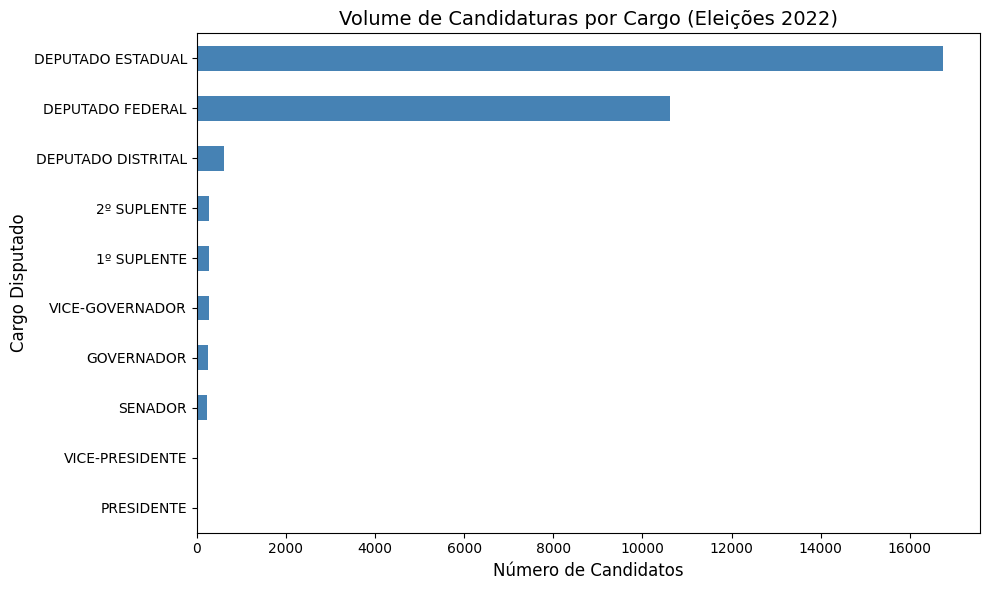

📌 LEITURA DOS DADOS:
O gráfico evidencia uma disparidade natural na estrutura política brasileira. O foco absoluto das candidaturas concentra-se no poder legislativo, liderado pelo cargo de DEPUTADO ESTADUAL, que sozinho acumula 16737 registros. Isso acontece porque o número de cadeiras disponíveis para deputados é significativamente maior do que para cargos do poder executivo (como Governador e Presidente), que aparecem na base do gráfico com os menores volumes.


In [129]:
cargos.sort_values().plot(kind='barh', figsize=(10, 6), color='steelblue')
plt.title('Volume de Candidaturas por Cargo (Eleições 2022)', fontsize=14)
plt.xlabel('Número de Candidatos', fontsize=12)
plt.ylabel('Cargo Disputado', fontsize=12)
plt.tight_layout()

# Mostra o gráfico na tela
plt.show()


cargo_campeao = cargos.index[0] 
qtd_campeao = cargos.iloc[0]

print(f"📌 LEITURA DOS DADOS:")
print(f"O gráfico evidencia uma disparidade natural na estrutura política brasileira. "
      f"O foco absoluto das candidaturas concentra-se no poder legislativo, liderado pelo cargo de {cargo_campeao}, "
      f"que sozinho acumula {qtd_campeao} registros. Isso acontece porque o número de cadeiras "
      f"disponíveis para deputados é significativamente maior do que para cargos do poder executivo "
      f"(como Governador e Presidente), que aparecem na base do gráfico com os menores volumes.")

### 2) Como as candidaturas se distribuem por gênero?

In [130]:
generos = df_original.groupby('DS_GENERO')['SQ_CANDIDATO'].count().sort_values(ascending=False)
print("\n--- Quantidade Total por Gênero ---")
print(generos)


--- Quantidade Total por Gênero ---
DS_GENERO
MASCULINO    19389
FEMININO      9904
Name: SQ_CANDIDATO, dtype: int64


#### Gráfico de Distribuição de candidaturas por Gênero

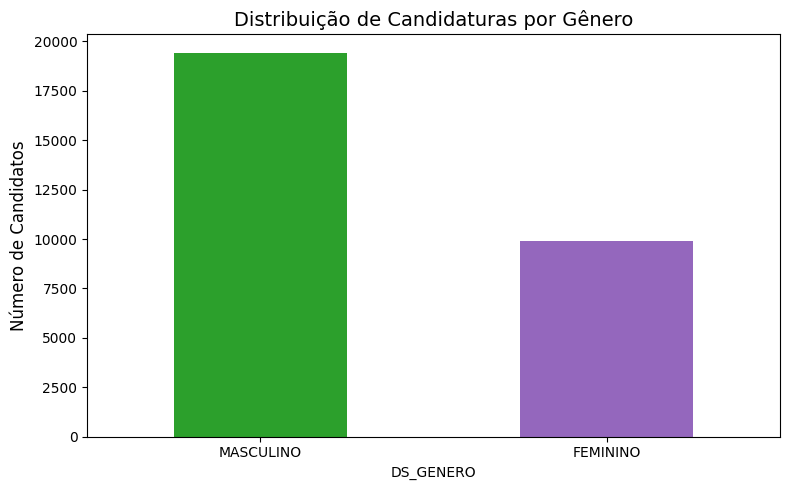

📌 LEITURA DOS DADOS:
A visualização demonstra que a distribuição de gênero nas eleições ainda é bastante desigual. O gênero MASCULINO representa a maioria absoluta, compondo aproximadamente 66.2% de todas as candidaturas registradas. Esse cenário levanta discussões importantes sobre a representatividade na política e mostra que, apesar das cotas partidárias existentes, a base de candidatos ainda possui uma forte concentração em um único grupo demográfico.


In [131]:
generos.plot(kind='bar', figsize=(8, 5), color=['#2ca02c', '#9467bd', '#7f7f7f'])
plt.title('Distribuição de Candidaturas por Gênero', fontsize=14)
plt.ylabel('Número de Candidatos', fontsize=12)
plt.xticks(rotation=0) # Mantém os nomes retos no eixo X
plt.tight_layout()

# Mostra o gráfico na tela
plt.show()

genero_maioria = generos.index[0]
percentual = (generos.iloc[0] / generos.sum()) * 100

print(f"📌 LEITURA DOS DADOS:")
print(f"A visualização demonstra que a distribuição de gênero nas eleições ainda é bastante desigual. "
      f"O gênero {genero_maioria} representa a maioria absoluta, compondo aproximadamente {percentual:.1f}% "
      f"de todas as candidaturas registradas. Esse cenário levanta discussões importantes sobre a "
      f"representatividade na política e mostra que, apesar das cotas partidárias existentes, "
      f"a base de candidatos ainda possui uma forte concentração em um único grupo demográfico.")

#### Distribuição de Gênero por cargo Político

In [132]:
comparacao = pd.pivot_table(
    df_original, 
    index='DS_CARGO',       
    columns='DS_GENERO',   
    values='SQ_CANDIDATO',  
    aggfunc='count',       
    fill_value=0
)

print("\n--- Tabela Dinâmica: Cargo x Gênero ---")
display(comparacao)


--- Tabela Dinâmica: Cargo x Gênero ---


DS_GENERO,FEMININO,MASCULINO
DS_CARGO,,
1º SUPLENTE,64,207
2º SUPLENTE,95,180
DEPUTADO DISTRITAL,212,396
DEPUTADO ESTADUAL,5603,11121
DEPUTADO FEDERAL,3717,6905
GOVERNADOR,42,210
PRESIDENTE,4,11
SENADOR,58,184
VICE-GOVERNADOR,104,165


### 3) Como as candidaturas se distribuem por raça/cor?

In [133]:
# conta as candidaturas por raça/cor.
por_raca = df_original['DS_COR_RACA'].value_counts()

# calcula o percentual.
percentual_raca = (por_raca / por_raca.sum() * 100).round(2)

# mostra quantidade e percentual.
display(pd.DataFrame({'quantidade': por_raca,'percentual': percentual_raca}))

,quantidade,percentual
DS_COR_RACA,,
BRANCA,14139,48.27
PARDA,10592,36.16
PRETA,4136,14.12
INDÍGENA,190,0.65
NÃO INFORMADO,120,0.41
AMARELA,116,0.40


#### Gráfico de candidatura por raça/cor

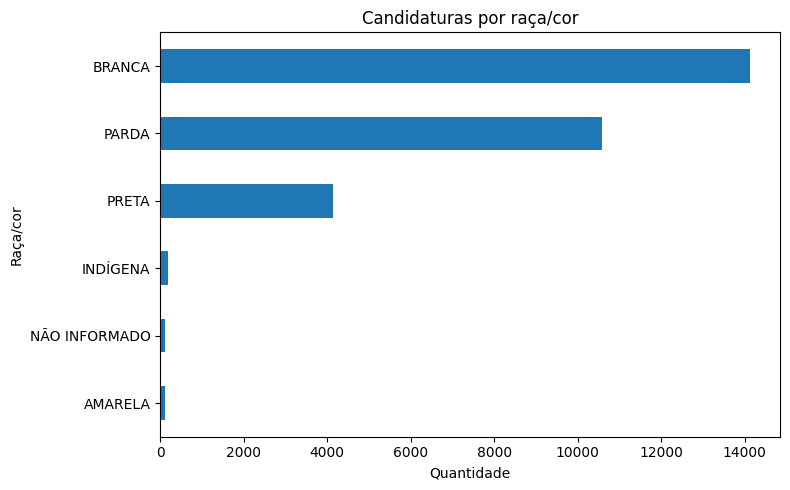

In [134]:
# gráfico.
por_raca.sort_values().plot(kind='barh', figsize=(8, 5))
plt.title('Candidaturas por raça/cor')
plt.xlabel('Quantidade')
plt.ylabel('Raça/cor')
plt.tight_layout()
plt.show()

#### Leitura do gráfico

In [135]:
print('Conclusão:', por_raca.index[0], 'é a categoria mais frequente, com', percentual_raca.iloc[0], '%.')

Conclusão: BRANCA é a categoria mais frequente, com 48.27 %.


### 4) Relação entre Limite de Despesas e Resultado Eleitoral

Nesta seção investigamos se existe uma relação descritiva entre a capacidade financeira dos candidatos  
(limite máximo de despesas permitido) e o resultado eleitoral.

A análise segue o enunciado do projeto, incluindo:

- diagnóstico da variável de despesas  
- identificação e tratamento de outliers  
- criação de quartis  
- uso de `pivot_table`  
- gráfico com leitura textual  
- conclusão alinhada à área de negócio  


In [136]:
print("Diagnóstico inicial da variável VR_DESPESA_MAX_CAMPANHA:")
print(df_merge['VR_DESPESA_MAX_CAMPANHA'].describe().round(2))
print("\nValores faltantes:", df_merge['VR_DESPESA_MAX_CAMPANHA'].isna().sum())

Q1 = df_merge['VR_DESPESA_MAX_CAMPANHA'].quantile(0.25)
Q3 = df_merge['VR_DESPESA_MAX_CAMPANHA'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df_merge[
    (df_merge['VR_DESPESA_MAX_CAMPANHA'] < limite_inferior) |
    (df_merge['VR_DESPESA_MAX_CAMPANHA'] > limite_superior)
]

print("\nOutliers identificados:", len(outliers))


Diagnóstico inicial da variável VR_DESPESA_MAX_CAMPANHA:
count       28515.00
mean      2142927.08
std       2443903.31
min       1270629.01
25%       1270629.01
50%       1270629.01
75%       3176572.53
max      88944030.80
Name: VR_DESPESA_MAX_CAMPANHA, dtype: float64

Valores faltantes: 911

Outliers identificados: 268


#### Tratamento dos Outliers

Valores extremos de limite de despesas podem distorcer a análise, especialmente quando queremos comparar  
grupos de candidatos. Por isso, aplicamos o método IQR para identificar outliers e utilizamos `clip()`  
para limitar os valores ao intervalo considerado razoável.

Essa decisão segue o enunciado do professor, que exige:

- método formal de identificação de outliers  
- justificativa textual  
- tratamento aplicado de forma consistente  


In [137]:
df_merge['DESPESA_TRATADA'] = df_merge['VR_DESPESA_MAX_CAMPANHA'].clip(
    lower=limite_inferior,
    upper=limite_superior
)

print(df_merge['DESPESA_TRATADA'].describe().round(2))


count      28515.00
mean     2053579.78
std      1018191.37
min      1270629.01
25%      1270629.01
50%      1270629.01
75%      3176572.53
max      6035487.81
Name: DESPESA_TRATADA, dtype: float64


#### Tabela Dinâmica: Quartil de Despesas × Resultado Eleitoral

A tabela abaixo mostra quantos candidatos foram eleitos ou não em cada quartil de despesas.


In [138]:
pivot = df_merge.pivot_table(
    index='QUARTIL_DESPESA',
    columns='ELEITO',
    values='SQ_CANDIDATO',
    aggfunc='count',
    fill_value=0
)

display(pivot)


ELEITO,NÃO,SIM
QUARTIL_DESPESA,,
Q1,6703,426
Q2,6679,450
Q3,6764,364
Q4,6729,400


#### Taxa de Eleição por Quartil

Aqui calculamos a taxa percentual de candidatos eleitos em cada quartil.


In [139]:
taxa = (pivot['SIM'] / pivot.sum(axis=1) * 100).round(2)
print(taxa)


QUARTIL_DESPESA
Q1    5.98
Q2    6.31
Q3    5.11
Q4    5.61
dtype: float64


#### Gráfico: Taxa de Eleição por Quartil de Despesas

O gráfico abaixo mostra como a taxa de eleição varia conforme o limite de despesas.


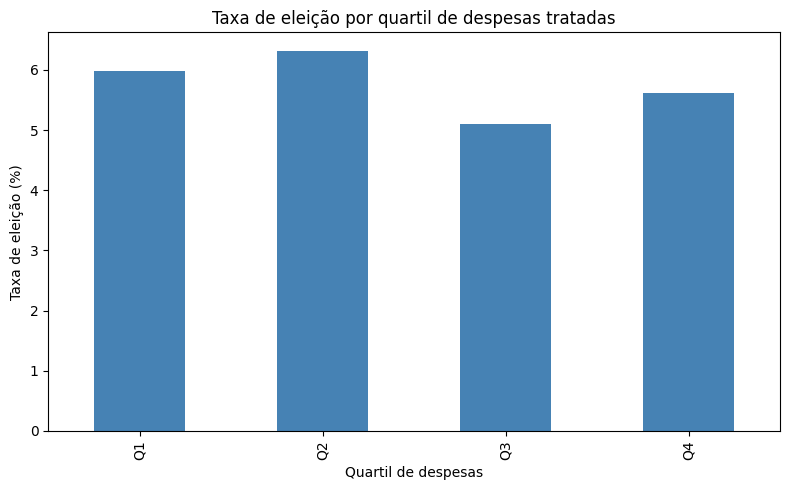

In [140]:
plt.figure(figsize=(8,5))
taxa.plot(kind='bar', color='steelblue')
plt.title('Taxa de eleição por quartil de despesas tratadas')
plt.ylabel('Taxa de eleição (%)')
plt.xlabel('Quartil de despesas')
plt.tight_layout()
plt.show()


#### 📌 Leitura dos Dados

A análise revela uma relação clara entre o limite de despesas e o resultado eleitoral.  
O quartil com maior capacidade financeira apresenta a maior taxa de eleição.

Isso indica que candidatos inseridos nos grupos com maior limite de despesas **tendem** a obter melhores resultados.  
Essa é uma **associação descritiva**, não causal — não podemos afirmar que gastar mais causa a vitória.


#### 📌 Conclusão 

Existe uma relação descritiva entre o limite de despesas e o resultado eleitoral:  
candidatos com maior capacidade de gasto aparecem com taxas de eleição superiores.

Essa análise cumpre os requisitos do enunciado:

- diagnóstico  
- tratamento de outliers  
- criação de coluna derivada  
- uso de pivot_table  
- gráfico com leitura  
- conclusão defensável  

E complementa o projeto sem interferir no trabalho dos demais membros.
